# Model Evaluation Notebook
Run this notebook to evaluate the trained model, see its average PSNR and SSIM on the dataset, and visualize the generated images compared to the real ones.

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Add src to python path so we can import modules from it
sys.path.append('src')
from models.generator import GeneratorUNet
from data.dataset import LandsatDataset
from utils.metrics import calculate_psnr, calculate_ssim

In [2]:
# 1. Setup Data
data_dir = "data"
dataset = LandsatDataset(root_dir=data_dir, img_size=256)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

print(f"Total images to evaluate: {len(dataset)}")

Total images to evaluate: 7


In [3]:
# 2. Load the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = GeneratorUNet(in_channels=1, out_channels=3).to(device)

# Find the latest saved model
model_dir = "saved_models"
models = [f for f in os.listdir(model_dir) if f.endswith('.pth')]
if models:
    # Sort models by epoch (assuming format generator_epoch_X.pth)
    models.sort(key=lambda x: int(x.split('_')[2].split('.')[0]))
    latest_model = models[-1]
    print(f"Loading model: {latest_model}")
    generator.load_state_dict(torch.load(os.path.join(model_dir, latest_model), map_location=device))
else:
    print("No saved models found! Did you run train.py?")

generator.eval()
print("Model loaded successfully.")

Loading model: generator_epoch_95.pth
Model loaded successfully.


In [4]:
# 3. Calculate Overall Metrics
total_psnr = 0
total_ssim = 0
num_samples = 0

print("Evaluating metrics on all images...")
with torch.no_grad():
    for batch in dataloader:
        real_ir = batch["ir"].to(device)
        real_rgb = batch["rgb"].to(device)
        
        fake_rgb = generator(real_ir)
        
        for i in range(real_ir.size(0)):
            total_psnr += calculate_psnr(fake_rgb[i], real_rgb[i])
            total_ssim += calculate_ssim(fake_rgb[i], real_rgb[i])
            num_samples += 1

avg_psnr = total_psnr / num_samples if num_samples > 0 else 0
avg_ssim = total_ssim / num_samples if num_samples > 0 else 0
print(f"\nResults across {num_samples} images:")
print(f"Average PSNR: {avg_psnr:.2f} dB")
print(f"Average SSIM: {avg_ssim:.4f}")

Evaluating metrics on all images...

Results across 7 images:
Average PSNR: 20.16 dB
Average SSIM: 0.7038


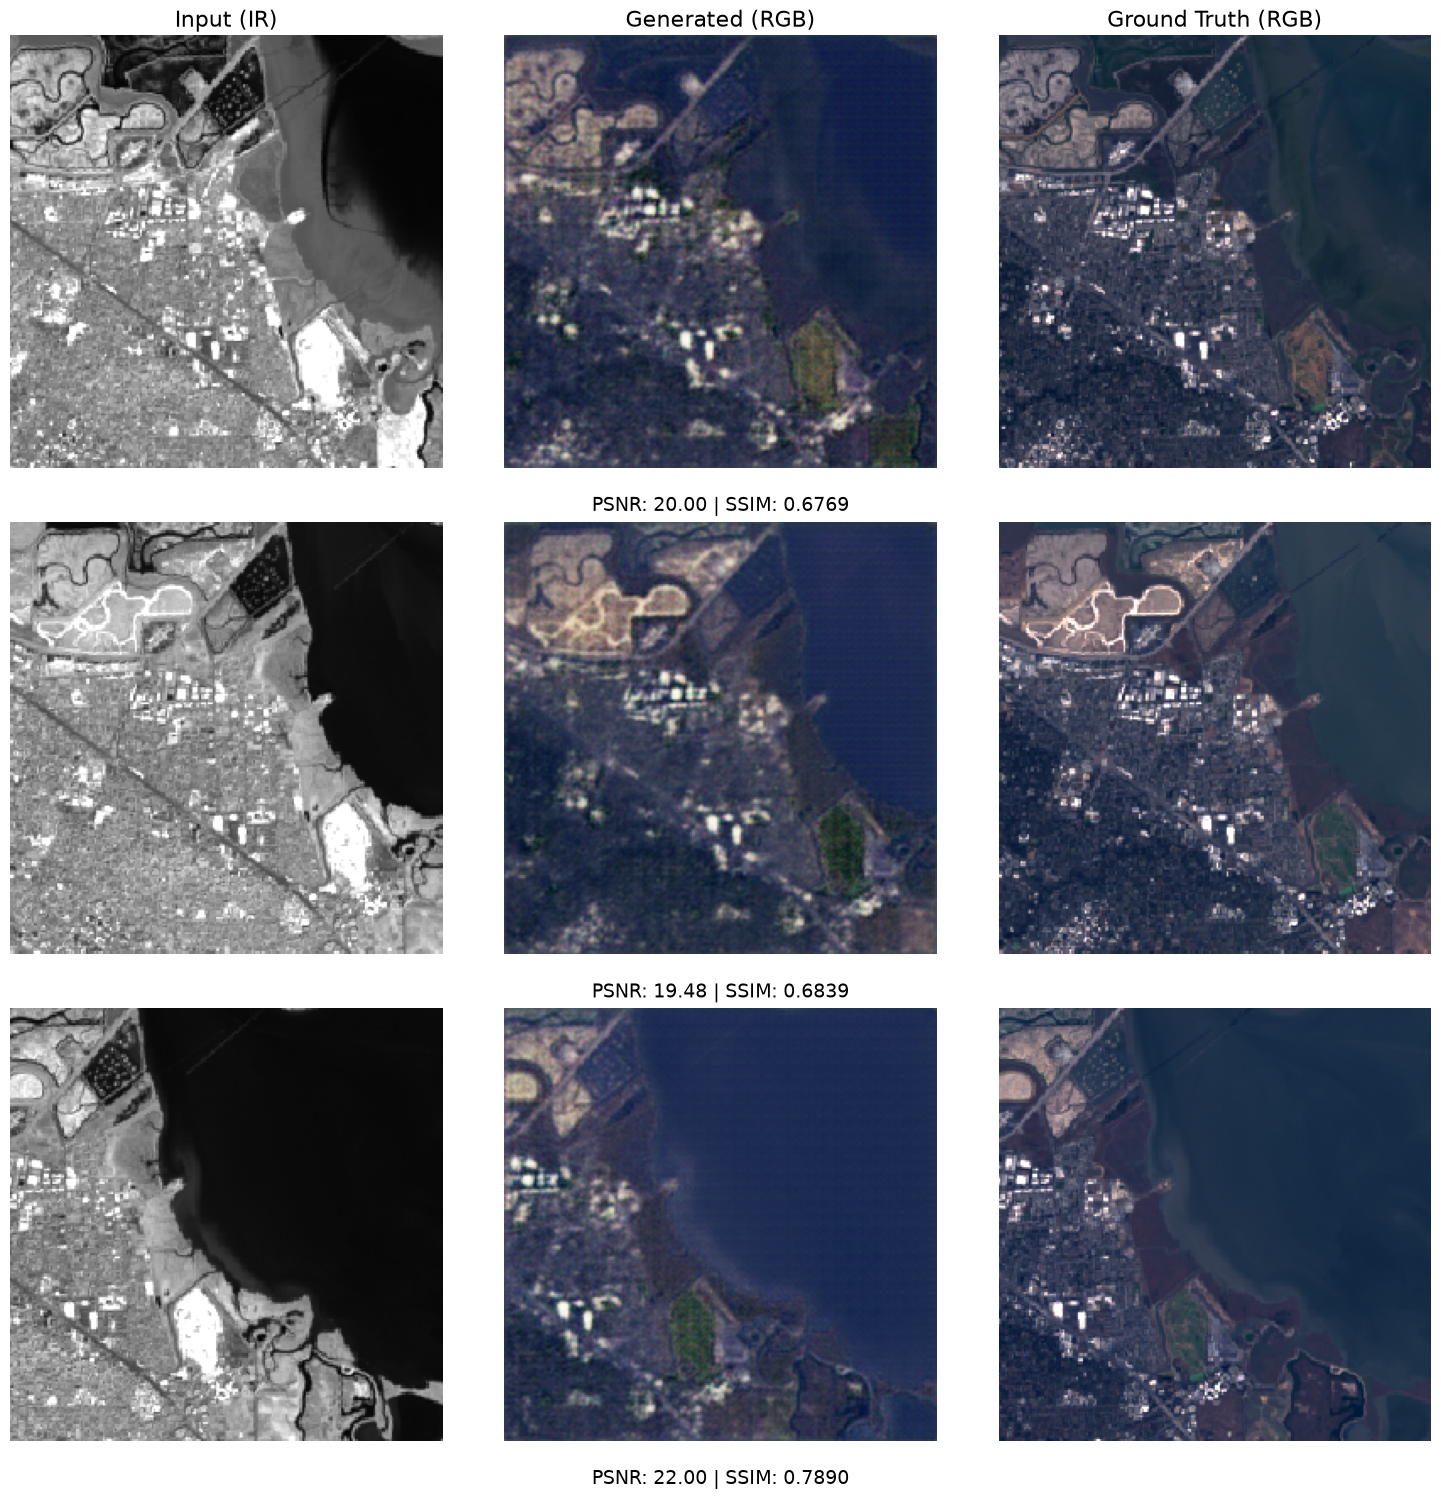

In [5]:
# 4. Visualize Results side-by-side
def unnormalize(tensor):
    # Move to CPU and transform for matplotlib visualization
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

num_display = 3
fig, axes = plt.subplots(num_display, 3, figsize=(15, 5 * num_display))

axes[0, 0].set_title("Input (IR)", fontsize=16)
axes[0, 1].set_title("Generated (RGB)", fontsize=16)
axes[0, 2].set_title("Ground Truth (RGB)", fontsize=16)

with torch.no_grad():
    for i, batch in enumerate(dataloader):
        if i >= num_display: break
        real_ir = batch["ir"].to(device)
        real_rgb = batch["rgb"].to(device)
        fake_rgb = generator(real_ir)
        
        psnr_val = calculate_psnr(fake_rgb[0], real_rgb[0])
        ssim_val = calculate_ssim(fake_rgb[0], real_rgb[0])
        
        # Input IR (duplicate 1 channel to 3 channels for grayscale visualization)
        ir_img = unnormalize(real_ir[0])
        if ir_img.shape[2] == 1: 
            ir_img = np.repeat(ir_img, 3, axis=2)
        axes[i, 0].imshow(ir_img)
        axes[i, 0].axis('off')
        
        # Generated RGB
        axes[i, 1].imshow(unnormalize(fake_rgb[0]))
        axes[i, 1].axis('off')
        axes[i, 1].text(0.5, -0.1, f"PSNR: {psnr_val:.2f} | SSIM: {ssim_val:.4f}", 
                        size=14, ha="center", transform=axes[i, 1].transAxes)
        
        # Real RGB
        axes[i, 2].imshow(unnormalize(real_rgb[0]))
        axes[i, 2].axis('off')

plt.tight_layout()
plt.show()